In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from tifffile import imread
from scipy.spatial import ConvexHull
from matplotlib.patches import Polygon

In [18]:
# ==== Input folder path ====
suite2p_dir = '/Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk301/mk301_02_27_2025/suite2p_full_output/plane_3/suite2p/plane0'  # Change this

# ==== Load files ====
stat = np.load(os.path.join(suite2p_dir, 'stat.npy'), allow_pickle=True)
iscell = np.load(os.path.join(suite2p_dir, 'iscell.npy'))
cell_labels = np.load(os.path.join(suite2p_dir, 'cell_labels.npy'))  # 1=inh, 0=exc

# ==== Filter based on cell probability threshold ====
threshold = 0.3
cell_probabilities = iscell[:, 1]
valid_cell_indices = np.where(cell_probabilities >= threshold)[0]

filtered_stat = [stat[i] for i in valid_cell_indices]
filtered_labels = [cell_labels[i] for i in valid_cell_indices]

# ==== Print info ====
n_total = len(iscell)
n_valid = len(valid_cell_indices)
print(f"Total cells: {n_total}")
print(f"Cells with probability ≥ {threshold}: {n_valid}")


Total cells: 4969
Cells with probability ≥ 0.3: 528


In [35]:
mean_image_path = '/Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk301/mk301_02_27_2025/green_processed/plane_12/plane_12_frames_0_to_3000_mean_autocontrast.tiff'  # Change this
mean_img = imread(mean_image_path)

# Optional: print shape for verification
print(f"Mean image shape: {mean_img.shape}")

Mean image shape: (456, 448)


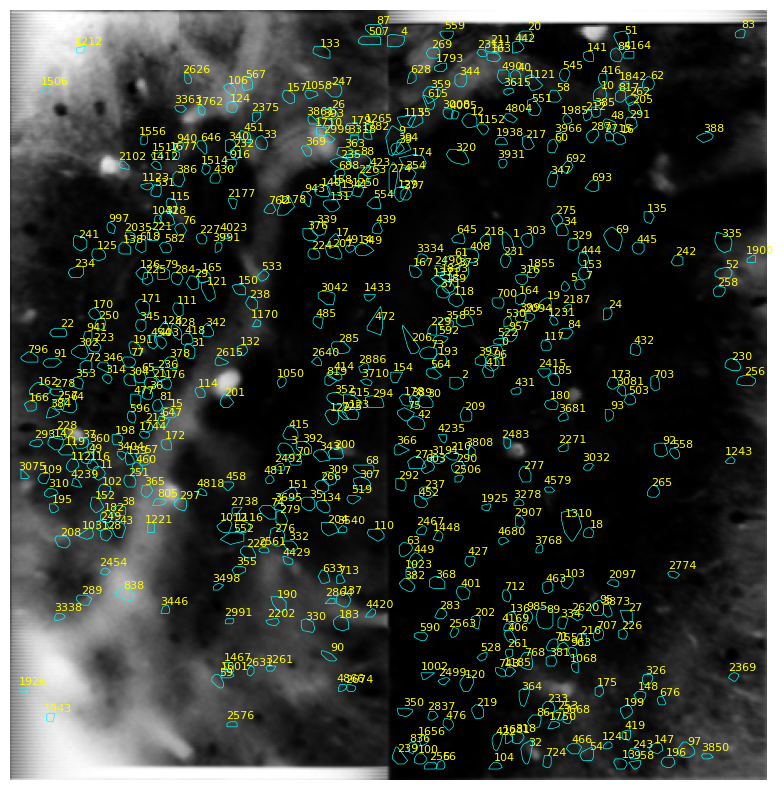

In [36]:
# === indices to exclude from plotting ===
exclude_indices = {1308, 1218, 1245, 1934, 1788, 1491, 1804, 1519, 1813, 1359, 1748, 1316, 1008, 2017, 2419, 1477, 1397, 1770, 1806, 1665} 

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(mean_img, cmap='gray')

for idx in valid_cell_indices:
    # skip excluded cells
    if idx in exclude_indices:
        continue

    cell = stat[idx]
    xpix = cell['xpix'].astype(int)
    ypix = cell['ypix'].astype(int)
    
    if xpix.size < 3:
        continue  # need at least 3 points for a polygon

    coords = np.column_stack((xpix, ypix))
    try:
        hull = ConvexHull(coords)
        outline = coords[hull.vertices]
        
        # draw footprint outline
        poly = Polygon(outline, closed=True, fill=False,
                       edgecolor='cyan', linewidth=0.5)
        ax.add_patch(poly)
        
        # choose your offset in pixels (or data units)
        dx, dy = 5, -5  

        centroid = coords.mean(axis=0)
        x_txt = centroid[0] + dx
        y_txt = centroid[1] + dy

        ax.text(x_txt, y_txt, str(idx),
        color='yellow', fontsize=8,
        ha='center', va='center')
    except Exception:
        continue  # skip if hull fails

ax.axis('off')
plt.tight_layout()
plt.show()

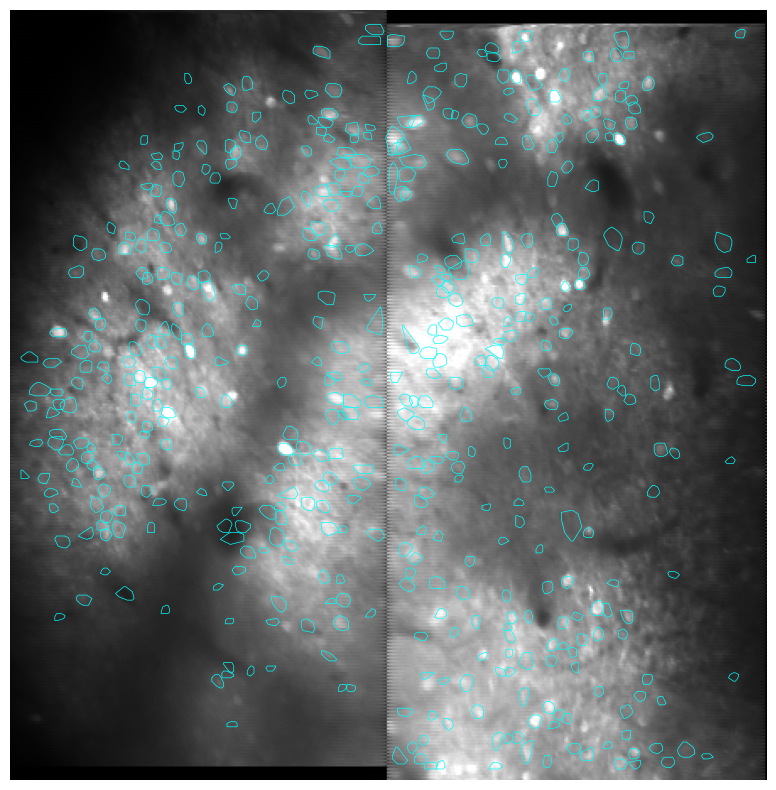

In [32]:
# === define which cell indices to exclude ===
exclude_indices = {89, 1926, 1943, 1308, 1218, 1245, 1934, 1788, 1491, 1804, 1519, 1813, 1359, 1748, 1316, 1008, 2017, 2419, 1477, 1397, 1770, 1212, 1665, 1506, 1212}  # example: skip cells 3, 7, and 12

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(mean_img, cmap='gray')

for idx in valid_cell_indices:
    if idx in exclude_indices:
        continue  # skip any indices in the exclusion set

    cell = stat[idx]
    xpix = cell['xpix'].astype(int)
    ypix = cell['ypix'].astype(int)
    
    if xpix.size < 3:
        continue  # need at least 3 points for a polygon

    coords = np.column_stack((xpix, ypix))
    try:
        hull = ConvexHull(coords)
        outline = coords[hull.vertices]
        poly = Polygon(outline, closed=True, fill=False,
                       edgecolor='cyan', linewidth=0.5)
        ax.add_patch(poly)
    except Exception:
        continue  # skip if hull fails


ax.axis('off')
plt.tight_layout()
plt.show()

Number of masks (excluding background): 274


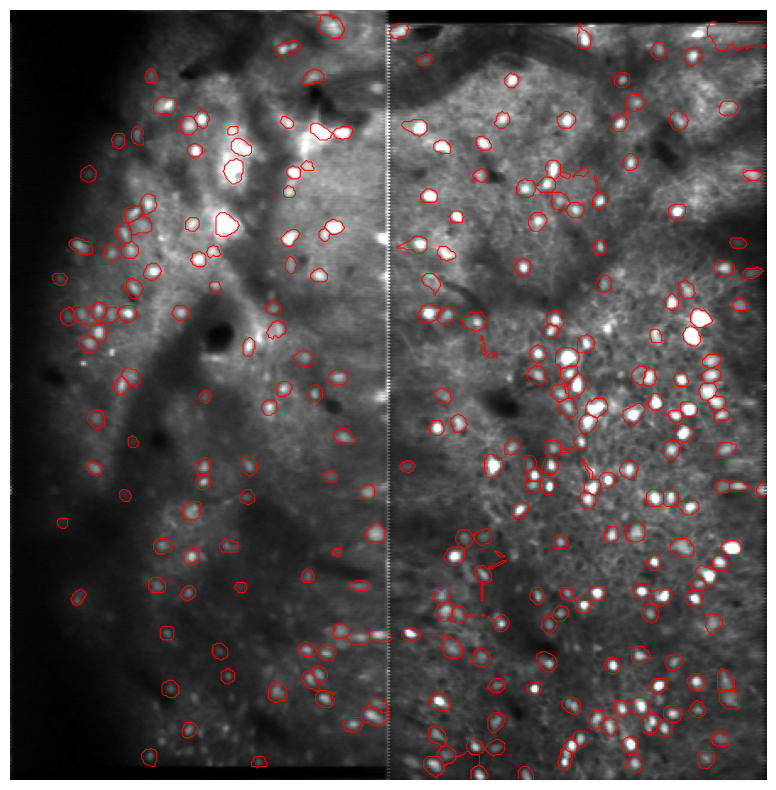

In [162]:
# ── USER PARAMETERS ──────────────────────────────────────────────────────────
mean_img_path = '/Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk301/mk301_02_10_2025/red_registered_before_only_processed/plane_12/plane_12_frames_0_to_1000_mean_autocontrast.tiff'
seg_path      = '/Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk301/mk301_02_10_2025/cellpose_red/plane_12_mean_image_masks_seg.npy'

# ── LOAD DATA ────────────────────────────────────────────────────────────────
mean_img = imread(mean_img_path)
seg      = np.load(seg_path)   # integer mask (0=background, 1,2,3...=cells)

# ── COUNT MASKS ──────────────────────────────────────────────────────────────
mask_labels = np.unique(seg)
mask_labels = mask_labels[mask_labels != 0]  # exclude background
n_masks = mask_labels.size
print(f"Number of masks (excluding background): {n_masks}")

# ── PLOT ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(mean_img, cmap='gray')

# loop over each mask label and contour its binary mask
for lab in mask_labels:
    mask = (seg == lab).astype(int)
    ax.contour(mask, levels=[0.5], colors='red', linewidths=0.7)

ax.axis('off')
plt.tight_layout()
plt.show()

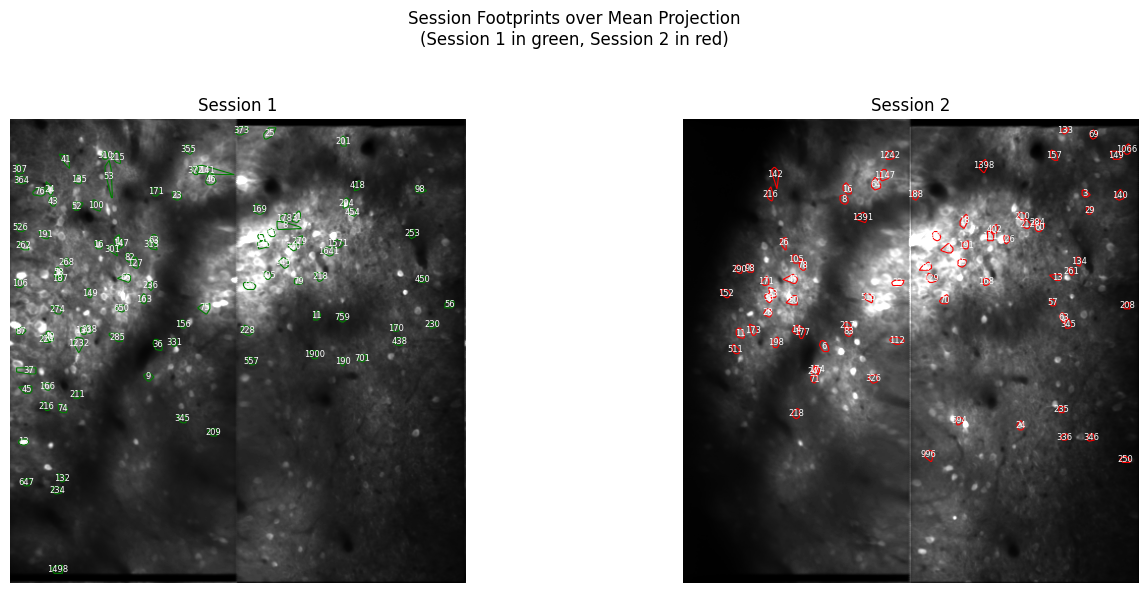

In [37]:
# ── USER PARAMETERS ──────────────────────────────────────────────────────────
session_dirs = {
    'Session 1': {
        'suite2p': '/Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk301/mk301_02_05_2025/suite2p_full_output/plane_8/suite2p/plane0',
        'mean_tiff': '/Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk301/mk301_02_05_2025/green_processed/plane_8/plane_8_frames_0_to_3000_mean_autocontrast.tiff'
    },
    'Session 2': {
        'suite2p': '/Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk301/mk301_02_10_2025/suite2p_full_output/plane_8/suite2p/plane0',
        'mean_tiff': '/Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk301/mk301_02_10_2025/green_processed/plane_8/plane_8_frames_0_to_3000_mean_autocontrast.tiff'
    }
}
threshold = 0.9   # cell probability filter

# ── HELPER: load & threshold, return list of (original_index, stat_entry) ─────
def load_filtered_stat(folder, p_thr):
    stat   = np.load(os.path.join(folder, 'stat.npy'), allow_pickle=True)
    iscell = np.load(os.path.join(folder, 'iscell.npy'))
    good   = np.where(iscell[:,1] >= p_thr)[0]
    return [(int(i), stat[i]) for i in good]

# ── PLOTTING ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharex=True, sharey=True)

for ax, (label, paths), color in zip(axes, session_dirs.items(), ['green','red']):
    # load mean projection
    mean_img = imread(paths['mean_tiff'])
    ax.imshow(mean_img, cmap='gray')
    
    # load and filter stats
    fps = load_filtered_stat(paths['suite2p'], threshold)
    
    for idx, s in fps:
        xpix = s['xpix'].astype(int)
        ypix = s['ypix'].astype(int)
        if xpix.size < 3:
            continue
        
        coords = np.column_stack((xpix, ypix))
        try:
            hull    = ConvexHull(coords)
            outline = coords[hull.vertices]
        except Exception:
            outline = coords  # fallback
        
        # draw the ROI outline
        poly = Polygon(outline, closed=True, fill=False,
                       edgecolor=color, linewidth=0.8)
        ax.add_patch(poly)
        
        # annotate the cell index at the footprint centroid
        centroid = coords.mean(axis=0)
        ax.text(centroid[0], centroid[1], str(idx),
                color='white', fontsize=6, ha='center', va='center',)
    
    ax.set_title(label)
    ax.axis('off')

plt.suptitle('Session Footprints over Mean Projection\n(Session 1 in green, Session 2 in red)')
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

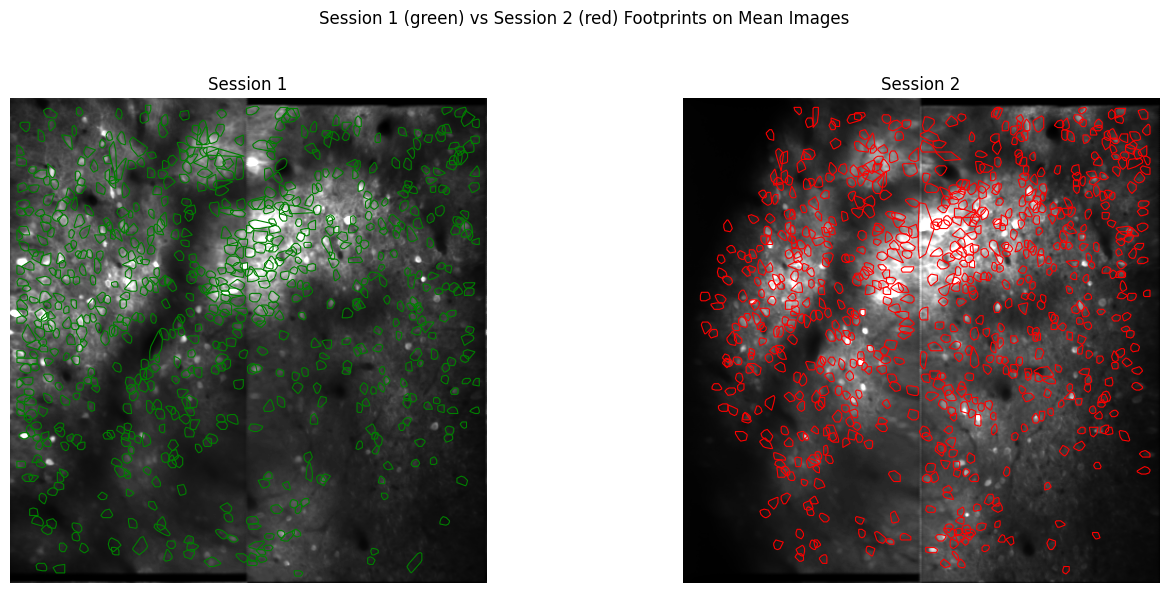

In [28]:
# ── USER PARAMETERS ──────────────────────────────────────────────────────────
session_dirs = {
    'Session 1': {
        'suite2p': '/Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk301/mk301_02_05_2025/suite2p_full_output/plane_8/suite2p/plane0',
        'mean_tiff': '/Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk301/mk301_02_05_2025/green_processed/plane_8/plane_8_frames_0_to_3000_mean_autocontrast.tiff'
    },
    'Session 2': {
        'suite2p': '/Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk301/mk301_02_10_2025/suite2p_full_output/plane_8/suite2p/plane0',
        'mean_tiff': '/Volumes/v-data2/kbarber/2025/mbo_lbm_proccessed/mk301/mk301_02_10_2025/green_processed/plane_8/plane_8_frames_0_to_3000_mean_autocontrast.tiff'
    }
}
threshold = 0.6   # cell probability filter

# ── HELPER: load & threshold stat.npy/iscell.npy ─────────────────────────────
def load_filtered_stat(folder, p_thr):
    stat   = np.load(os.path.join(folder, 'stat.npy'), allow_pickle=True)
    iscell = np.load(os.path.join(folder, 'iscell.npy'))
    good   = np.where(iscell[:,1] >= p_thr)[0]
    return [stat[i] for i in good]

# ── PLOTTING ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharex=True, sharey=True)

for ax, (label, paths), color in zip(axes, session_dirs.items(), ['green','red']):
    # load mean projection and footprints
    mean_img = imread(paths['mean_tiff'])
    fps      = load_filtered_stat(paths['suite2p'], threshold)
    
    # show background
    ax.imshow(mean_img, cmap='gray')
    
    # overlay each footprint
    for s in fps:
        xpix = s['xpix'].astype(int)
        ypix = s['ypix'].astype(int)
        if xpix.size < 3:
            continue
        coords = np.column_stack((xpix, ypix))
        try:
            hull    = ConvexHull(coords)
            outline = coords[hull.vertices]
            poly = Polygon(outline, closed=True, fill=False,
                           edgecolor=color, linewidth=0.8)
            ax.add_patch(poly)
        except Exception:
            continue
    
    ax.set_title(label)
    ax.axis('off')

plt.suptitle('Session 1 (green) vs Session 2 (red) Footprints on Mean Images')
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()